## 2D CSA

Instead of the standard P⋅u≤q, we find a threshold t such that the "Acceptance Region" is the union of local confidence intervals. By removing Host D, the points in the middle-right and top-middle are gone, and the boundary will naturally "collapse" inward because there are no points there to support a high threshold.

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors

In [34]:
np.random.seed(42)

### Data Simulation

In [35]:
def simulate_class_data(n, ratio_A, ratio_B, ratio_C):
    # Host A: Top Left
    n_A = int(n * ratio_A)
    A = np.random.multivariate_normal([0.15, 0.75], [[0.008, 0], [0, 0.008]], n_A)
    # Host B: Bottom Right
    n_B = int(n * ratio_B)
    B = np.random.multivariate_normal([0.75, 0.15], [[0.008, 0], [0, 0.008]], n_B)  

    n_C = int(n * ratio_C)
    C = np.random.multivariate_normal([0.15, 0.15], [[0.008, 0], [0, 0.008]], n_C)  
    
    all_scores = np.clip(np.vstack((A, B, C)), 0, 1)
    labels = np.array(['A']*n_A + ['B']*n_B + ['C']*n_C)
    return all_scores, labels

### Shape Discovery

In [36]:
def get_local_scores(query_points, calibration_points, k=5):
    """
    Score = distance to the k-th nearest neighbor in calibration data.
    Smaller score = point is 'inside' the data distribution.
    """
    nbrs = NearestNeighbors(n_neighbors=k).fit(calibration_points)
    distances, _ = nbrs.kneighbors(query_points)
    return distances[:, -1] # Distance to the k-th neighbor

### Size scaling

In [37]:
def calibrate_local_boundary(calib_scores, alpha, k=5):
    # Calculate self-distances to find the threshold
    scores = get_local_scores(calib_scores, calib_scores, k)
    t_hat = np.quantile(scores, 1 - alpha)
    return t_hat

### Visualization

In [38]:
def plot_local_inference(raw_scores, labels, t_hat, k, mystery_scores, alpha):
    plt.figure(figsize=(10, 8))
    
    # Plot Data
    colors = {'A': '#e41a1c', 'B': '#ff7f00', 'C' : 'purple'}
    for cls in ['A', 'B', 'C']:
        mask = labels == cls
        plt.scatter(raw_scores[mask, 0], raw_scores[mask, 1], 
                    c=colors[cls], label=f"Host {cls}", s=25, alpha=0.5)

    # Grid for the Local Boundary
    x = np.linspace(0, 1, 150)
    y = np.linspace(0, 1, 150)
    X, Y = np.meshgrid(x, y)
    grid = np.vstack([X.ravel(), Y.ravel()]).T
    
    grid_scores = get_local_scores(grid, raw_scores, k)
    # Point is 'inside' if its distance to calibration data is small enough
    inside = (grid_scores <= t_hat).reshape(X.shape)
    
    plt.contourf(X, Y, inside, levels=[0.5, 1], colors='blue', alpha=0.1)
    plt.contour(X, Y, inside, levels=[0.5], colors='blue', linewidths=2.5)

    # Test Points
    host_names = ['Test: Host A', 'Test: Host B', 'Test: Host C', 'Test: Host D']
    for i, score in enumerate(mystery_scores):
        s_val = get_local_scores(score.reshape(1, -1), raw_scores, k)
        is_accepted = s_val <= t_hat
        
        marker, color = ('P', 'darkblue') if is_accepted else ('X', 'black')
        plt.scatter(score[0], score[1], color=color, marker=marker, s=150, edgecolors='white', zorder=5)
        plt.text(score[0] + 0.02, score[1] + 0.02, host_names[i])

    plt.title(f"Local Adaptive Inference (k={k}, Alpha={alpha})\nBoundary wraps tightly around existing data clusters")
    plt.xlabel("Model 1 Error (P1)")
    plt.ylabel("Model 2 Error (P2)")
    plt.xlim(0, 1); plt.ylim(0, 1)
    plt.legend()
    plt.grid(alpha=0.2)
    plt.show()

execution

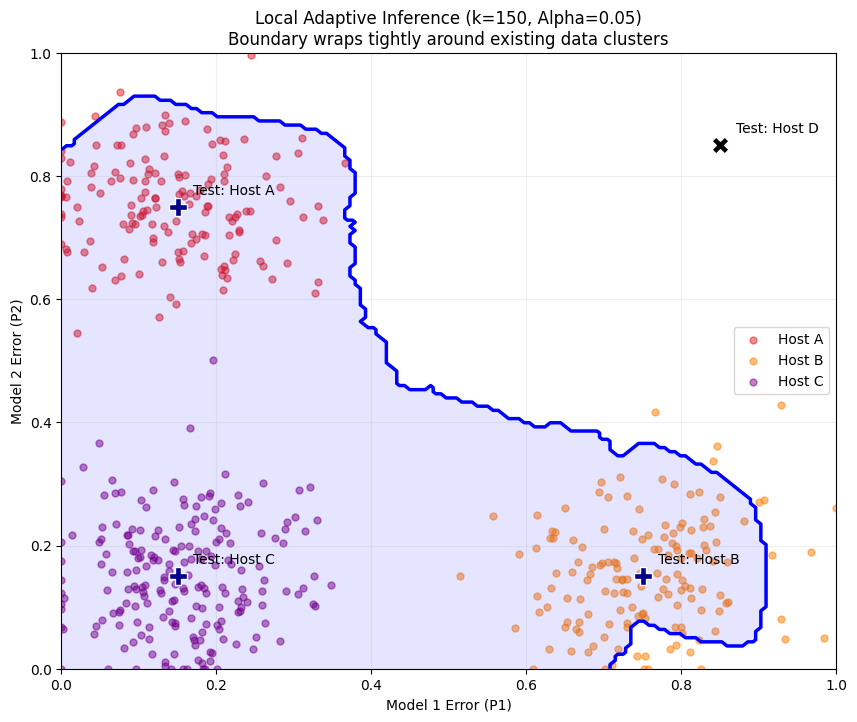

In [41]:
alpha = 0.05
k = 150 # Increase k for a smoother/broader shape, decrease for tighter fit

raw_scores, labels = simulate_class_data(500, 0.3, 0.3, 0.4)
t_hat = calibrate_local_boundary(raw_scores, alpha, k)

mystery_tests = np.array([
    [0.15, 0.75], # Near A
    [0.75, 0.15], # Near B
    [0.15, 0.15], # Empty corner (Should be rejected)
    [0.85, 0.85]  # Empty corner (Should be rejected)
])

plot_local_inference(raw_scores, labels, t_hat, k, mystery_tests, alpha)